# chat gpt generated code

In [ ]:
def is_valid(board, row, col, num):
    """ 指定した num を (row, col) に配置できるかチェック """
    # 行と列をチェック
    for i in range(9):
        if board[row][i] == num or board[i][col] == num:
            return False

    # 3x3 のボックスをチェック
    box_row, box_col = (row // 3) * 3, (col // 3) * 3
    for i in range(3):
        for j in range(3):
            if board[box_row + i][box_col + j] == num:
                return False

    return True

def solve_sudoku(board):
    """ 数独を解く関数 (バックトラッキング) """
    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:
                for num in range(1, 10):
                    if is_valid(board, row, col, num):
                        board[row][col] = num
                        if solve_sudoku(board):
                            return True
                        board[row][col] = 0  # 戻す (バックトラッキング)
                return False  # どの数値も入らない場合
    return True  # すべて埋まったら解決

def print_board(board):
    """ 数独の盤面を表示 """
    for row in board:
        print(" ".join(str(num) if num != 0 else '.' for num in row))

# テスト用の数独パズル (0 は空白を表す)
puzzle = [
    [8, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 3, 6, 0, 0, 0, 0, 0],
    [0, 7, 0, 0, 9, 0, 2, 0, 0],
    [0, 5, 0, 0, 0, 7, 0, 0, 0],
    [0, 0, 0, 0, 4, 5, 7, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 3, 0],
    [0, 0, 1, 0, 0, 0, 0, 6, 8],
    [0, 0, 8, 5, 0, 0, 0, 1, 0],
    [0, 9, 0, 0, 0, 0, 4, 0, 0]
]

print("元の数独:")
print_board(puzzle)

if solve_sudoku(puzzle):
    print("\n解いた数独:")
    print_board(puzzle)
else:
    print("\n解けませんでした。")

元の数独:
8 . . . . . . . .
. . 3 6 . . . . .
. 7 . . 9 . 2 . .
. 5 . . . 7 . . .
. . . . 4 5 7 . .
. . . 1 . . . 3 .
. . 1 . . . . 6 8
. . 8 5 . . . 1 .
. 9 . . . . 4 . .

解いた数独:
8 1 2 7 5 3 6 4 9
9 4 3 6 8 2 1 7 5
6 7 5 4 9 1 2 8 3
1 5 4 2 3 7 8 9 6
3 6 9 8 4 5 7 2 1
2 8 7 1 6 9 5 3 4
5 2 1 9 7 4 3 6 8
4 3 8 5 2 6 9 1 7
7 9 6 3 1 8 4 5 2


# 画像を入力して、二次元リストを生成

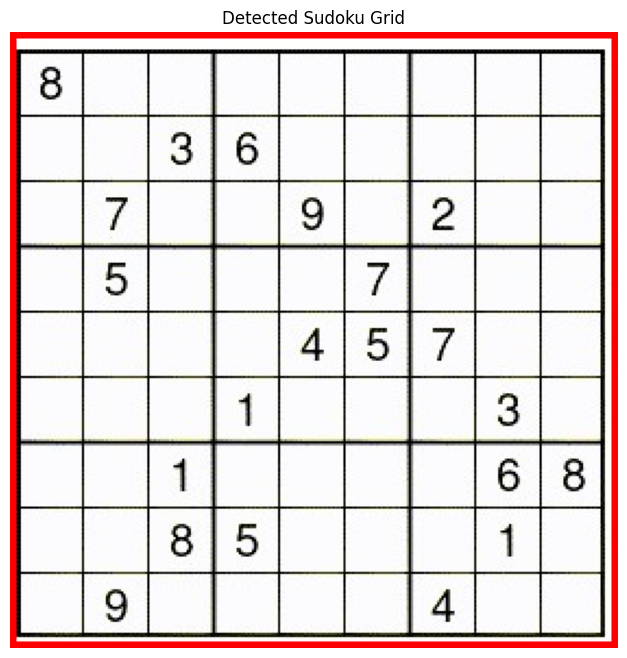

Rect coordinates: [[  0.   0.]
 [278.   0.]
 [  0. 282.]
 [278. 282.]]
side:282.0
Transformation matrix:
 [[ 1.01079137  0.          0.        ]
 [ 0.          0.9964539   0.        ]
 [-0.         -0.          1.        ]]


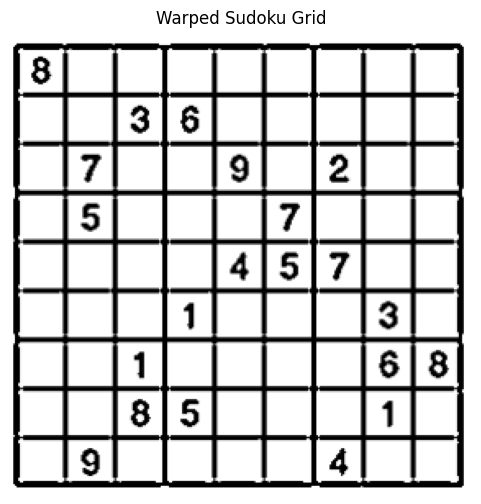

[[ 0  0  0  0  0  0  0  0  0]
 [ 0  0  5  6  0  0  0  0  0]
 [ 0  7  0  0  9  0  0  0  0]
 [ 0  0  0  0  0  7  0  0  0]
 [ 0  0  0  0  4  0  7  0  0]
 [ 0  0  0  0  0  0  0  3  0]
 [ 0  0  0  0  0  0  0  6  0]
 [ 0  0 18  0  0  0  0  4  0]
 [ 0 19  0  0  0  0  4  0  0]]


In [ ]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt

image_path = "sudoku.jpg"  # 画像のパス

def order_points(pts):
    """ 頂点の順番を [左上, 右上, 左下, 右下] に並べる """
    rect = np.zeros((4, 2), dtype="float32")

    # 各点の x + y の合計を計算（左上が最小, 右下が最大）
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # 左上 (Top-left)
    rect[3] = pts[np.argmax(s)]  # 右下 (Bottom-right)

    # 各点の x - y の差を計算（右上が最大, 左下が最小）
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # 右上 (Top-right)
    rect[2] = pts[np.argmax(diff)]  # 左下 (Bottom-left)

    return rect

def draw_detected_contour(image_path, contour):
    """ 検出した最大の四角形を元画像に重ねて表示 """
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("エラー: 画像の読み込みに失敗しました。")

    # 輪郭を描画（赤色, 太さ3px）
    cv2.drawContours(img, [contour], -1, (0, 0, 255), 3)

    # Matplotlib で表示
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Detected Sudoku Grid")
    plt.axis("off")
    plt.show()

def preprocess_image(image_path):
    """ 画像を前処理して数独盤面を抽出 """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return img

def find_largest_contour(image):
    """ 最大の四角形（数独盤面）を検出 """
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:
            return approx
    return None

def warp_perspective(image, contour):
    """ 数独盤面を透視変換して正面からのビューに補正 """
    pts = np.array([c[0] for c in contour], dtype='float32')
    if pts.shape[0] != 4:
        raise ValueError(f"エラー: 輪郭の頂点数が異常です。検出された頂点数: {pts.shape[0]}")
    s = pts.sum(axis=1)
    rect = order_points(pts)
    print("Rect coordinates:", rect)

    side = max(np.linalg.norm(rect[0] - rect[2]), np.linalg.norm(rect[1] - rect[3]))
    print(f"side:{side}")
    if side < 10:
        raise ValueError(f"エラー: 盤面サイズが小さすぎます。計算されたサイズ: {side}")
    dst = np.array([[0, 0], [side - 1, 0], [0, side - 1], [side - 1, side - 1]], dtype='float32')
    matrix = cv2.getPerspectiveTransform(rect, dst)
    print("Transformation matrix:\n", matrix)
    return cv2.warpPerspective(image, matrix, (int(side), int(side)))

def extract_digits(warped_image):
    """ 9×9 のセルを切り出して OCR で数字を認識 """
    grid = np.zeros((9, 9), dtype=int)
    cell_size = warped_image.shape[0] // 9

    for i in range(9):
        for j in range(9):
            x, y = j * cell_size, i * cell_size
            cell = warped_image[y:y + cell_size, x:x + cell_size]
            cell = cv2.resize(cell, (28, 28))

            # 数字をOCRで認識
            text = pytesseract.image_to_string(cell, config='--psm 10 digits')
            text = text.strip()
            grid[i, j] = int(text) if text.isdigit() else 0

    return grid

def process_sudoku(image_path):
    """ 画像から数独の2Dリストを生成 """
    img = preprocess_image(image_path)
    contour = find_largest_contour(img)
    draw_detected_contour(image_path, contour)
    if contour is None:
        raise ValueError("数独の盤面が見つかりませんでした。")

    warped = warp_perspective(img, contour)
    if warped is None or warped.sum() == 0:
        print("透視変換後の画像が真っ黒です。")

    # **画像を表示**
    plt.figure(figsize=(6, 6))
    plt.imshow(warped, cmap='gray')
    plt.title("Warped Sudoku Grid")
    plt.axis("off")
    plt.show()

    return extract_digits(warped)

# 使用例
sudoku_grid = process_sudoku(image_path)
print(sudoku_grid)

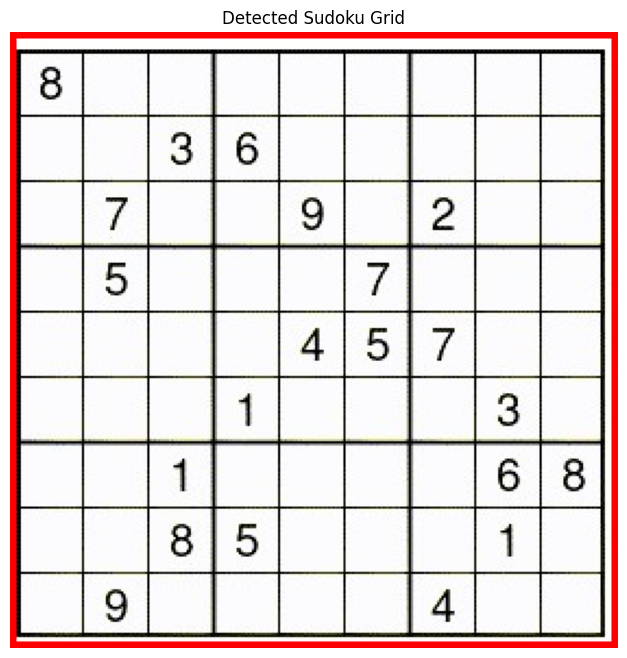

Rect coordinates: [[  0.   0.]
 [278.   0.]
 [  0. 282.]
 [278. 282.]]
side:282.0
Transformation matrix:
 [[ 1.01079137  0.          0.        ]
 [ 0.          0.9964539   0.        ]
 [-0.         -0.          1.        ]]


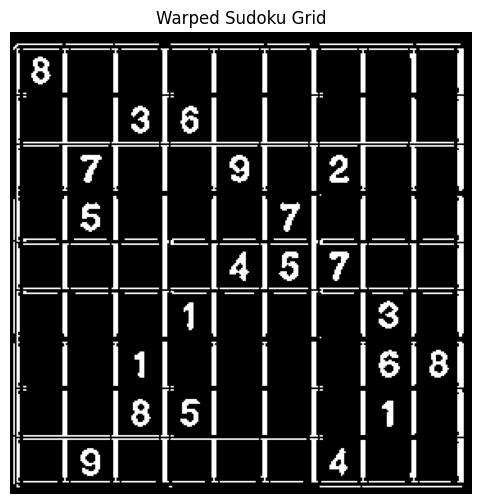

[[0 0 0 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0]
 [0 7 0 0 0 0 0 0 1]
 [0 5 0 0 0 7 0 1 0]
 [0 0 0 0 4 0 7 0 0]
 [0 0 0 1 0 0 0 3 0]
 [0 0 1 0 0 0 0 6 8]
 [0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 4 0 0]]


In [ ]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt

image_path = "sudoku.jpg"  # 画像のパス

def remove_grid_lines(image):
    """数独盤面からグリッド線を除去"""
    # 二値化
    thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # 横線の除去
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
    image_no_lines = cv2.subtract(thresh, detected_lines)

    # 縦線の除去
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    detected_lines = cv2.morphologyEx(image_no_lines, cv2.MORPH_OPEN, vertical_kernel, iterations=2)
    final_image = cv2.subtract(image_no_lines, detected_lines)

    return final_image

def order_points(pts):
    """ 頂点の順番を [左上, 右上, 左下, 右下] に並べる """
    rect = np.zeros((4, 2), dtype="float32")

    # 各点の x + y の合計を計算（左上が最小, 右下が最大）
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # 左上 (Top-left)
    rect[3] = pts[np.argmax(s)]  # 右下 (Bottom-right)

    # 各点の x - y の差を計算（右上が最大, 左下が最小）
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # 右上 (Top-right)
    rect[2] = pts[np.argmax(diff)]  # 左下 (Bottom-left)

    return rect

def draw_detected_contour(image_path, contour):
    """ 検出した最大の四角形を元画像に重ねて表示 """
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("エラー: 画像の読み込みに失敗しました。")

    # 輪郭を描画（赤色, 太さ3px）
    cv2.drawContours(img, [contour], -1, (0, 0, 255), 3)

    # Matplotlib で表示
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Detected Sudoku Grid")
    plt.axis("off")
    plt.show()

def preprocess_image(image_path):
    """ 画像を前処理して数独盤面を抽出 """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return img

def find_largest_contour(image):
    """ 最大の四角形（数独盤面）を検出 """
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:
            return approx
    return None

def warp_perspective(image, contour):
    """ 数独盤面を透視変換して正面からのビューに補正 """
    pts = np.array([c[0] for c in contour], dtype='float32')
    if pts.shape[0] != 4:
        raise ValueError(f"エラー: 輪郭の頂点数が異常です。検出された頂点数: {pts.shape[0]}")
    s = pts.sum(axis=1)
    rect = order_points(pts)
    print("Rect coordinates:", rect)

    side = max(np.linalg.norm(rect[0] - rect[2]), np.linalg.norm(rect[1] - rect[3]))
    print(f"side:{side}")
    if side < 10:
        raise ValueError(f"エラー: 盤面サイズが小さすぎます。計算されたサイズ: {side}")
    dst = np.array([[0, 0], [side - 1, 0], [0, side - 1], [side - 1, side - 1]], dtype='float32')
    matrix = cv2.getPerspectiveTransform(rect, dst)
    print("Transformation matrix:\n", matrix)
    return cv2.warpPerspective(image, matrix, (int(side), int(side)))

def extract_digits(warped_image):
    """ 9×9 のセルを切り出して OCR で数字を認識 """
    grid = np.zeros((9, 9), dtype=int)
    cell_size = warped_image.shape[0] // 9

    for i in range(9):
        for j in range(9):
            x, y = j * cell_size, i * cell_size
            cell = warped_image[y:y + cell_size, x:x + cell_size]
            cell = cv2.resize(cell, (28, 28))

            # 数字をOCRで認識
            text = pytesseract.image_to_string(cell, config='--psm 10 digits')
            text = text.strip()
            grid[i, j] = int(text) if text.isdigit() else 0

    return grid

def process_sudoku(image_path):
    """ 画像から数独の2Dリストを生成 """
    img = preprocess_image(image_path)
    contour = find_largest_contour(img)
    draw_detected_contour(image_path, contour)
    if contour is None:
        raise ValueError("数独の盤面が見つかりませんでした。")

    warped = warp_perspective(img, contour)
    if warped is None or warped.sum() == 0:
        print("透視変換後の画像が真っ黒です。")


    processed_img = remove_grid_lines(warped)

    # **画像を表示**
    plt.figure(figsize=(6, 6))
    plt.imshow(processed_img, cmap='gray')
    plt.title("Warped Sudoku Grid")
    plt.axis("off")
    plt.show()

    return extract_digits(processed_img)

# 使用例
sudoku_grid = process_sudoku(image_path)
print(sudoku_grid)

# EasyOCRを使う

EasyOCR単体はゴミ

![](easyocr.png)

In [5]:
import easyocr

reader = easyocr.Reader(['en'])  # 英数字のみを認識

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


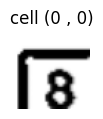

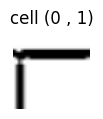

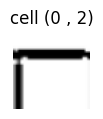

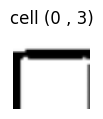

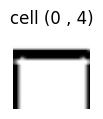

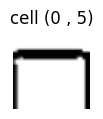

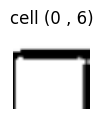

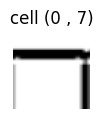

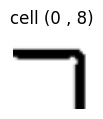

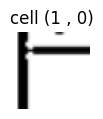

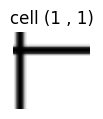

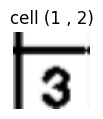

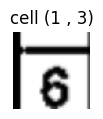

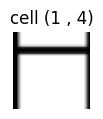

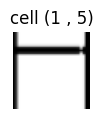

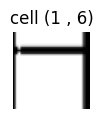

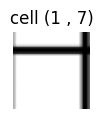

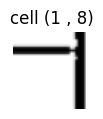

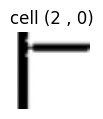

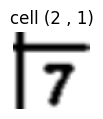

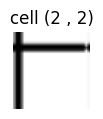

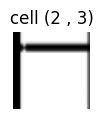

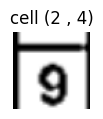

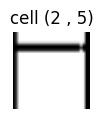

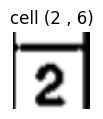

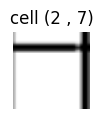

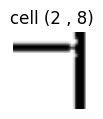

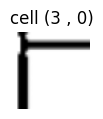

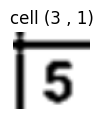

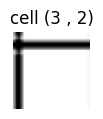

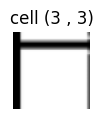

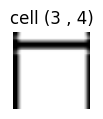

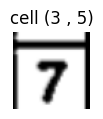

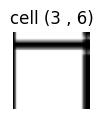

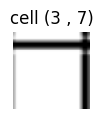

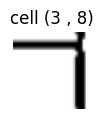

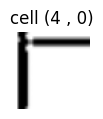

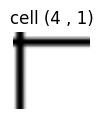

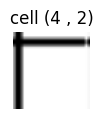

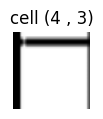

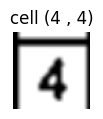

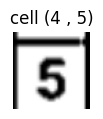

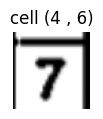

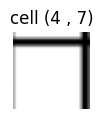

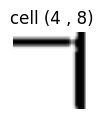

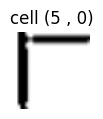

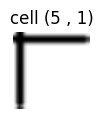

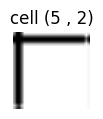

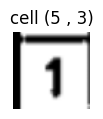

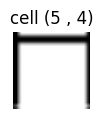

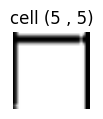

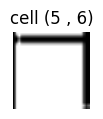

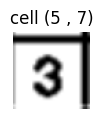

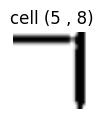

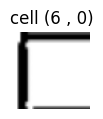

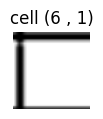

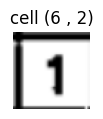

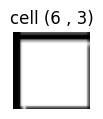

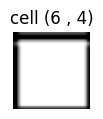

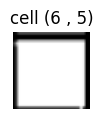

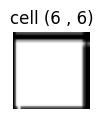

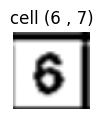

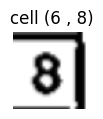

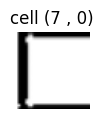

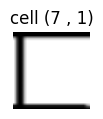

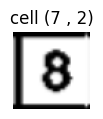

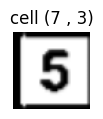

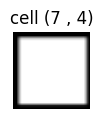

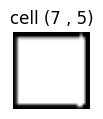

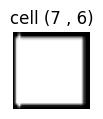

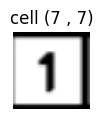

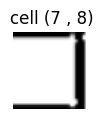

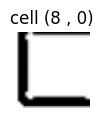

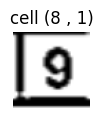

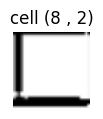

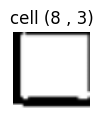

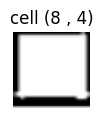

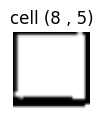

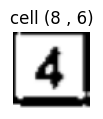

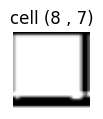

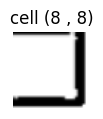

[[ 18   0   0   0   0   0   0   0   0]
 [  0   0   3 167   0   0   0   0   0]
 [  0   0   0   0   9   0   2   0   0]
 [  0  15   0   0   0   0   0   0   0]
 [  0   0   0   0   0   5   7   0   0]
 [  0   0   0   0   0   0   0   3   0]
 [  0   0   0   0   0   0   0   6   8]
 [  0   0   8   5   0   0   0   0   0]
 [  0  19   0   0   0   0   0   0   0]]


In [ ]:
def preprocess_image(image_path):
    """ 画像を前処理して数独盤面を抽出 """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return img

def find_largest_contour(image):
    """ 最大の四角形（数独盤面）を検出 """
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:
            return approx
    return None

def warp_perspective(image, contour):
    """ 数独盤面を透視変換して正面からのビューに補正 """
    pts = np.array([c[0] for c in contour], dtype='float32')
    if pts.shape[0] != 4:
        raise ValueError("エラー: 輪郭の頂点が4点ではありません。")

    # 頂点の順番を並び替え
    rect = order_points(pts)

    side = max(np.linalg.norm(rect[0] - rect[2]), np.linalg.norm(rect[1] - rect[3]))
    dst = np.array([[0, 0], [side - 1, 0], [0, side - 1], [side - 1, side - 1]], dtype='float32')
    matrix = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, matrix, (int(side), int(side)))
    return warped

def extract_digits_easyocr(warped_image):
    """ 9×9 のセルを切り出して EasyOCR で数字を認識 """
    reader = easyocr.Reader(['en'])
    grid = np.zeros((9, 9), dtype=int)
    cell_size = warped_image.shape[0] // 9

    for i in range(9):
        for j in range(9):
            x, y = j * cell_size, i * cell_size
            cell = warped_image[y:y + cell_size, x:x + cell_size]
            cell = cv2.resize(cell, (56, 56))

            # **画像を表示**
            plt.figure(figsize=(1, 1))
            plt.imshow(cell, cmap='gray')
            plt.title(f"cell ({i} , {j})")
            plt.axis("off")
            plt.show()

            # EasyOCR で文字認識
            results = reader.readtext(cell, detail=0)
            digit = ''.join([r for r in results if r.isdigit()])
            grid[i, j] = int(digit) if digit else 0

    return grid

def process_sudoku(image_path):
    """ 画像から数独の2Dリストを生成 """
    img = preprocess_image(image_path)
    contour = find_largest_contour(img)
    if contour is None:
        raise ValueError("数独の盤面が見つかりませんでした。")

    warped = warp_perspective(img, contour)
    return extract_digits_easyocr(warped)

# 使用例
image_path = "sudoku.jpg"  # 画像のパス
sudoku_grid = process_sudoku(image_path)
print(sudoku_grid)


EasyOCR単体はゴミ

![](easyocr.png)

# 切り出したセルの端を白く塗りつぶす処理をいれる

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


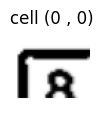

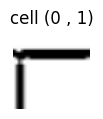

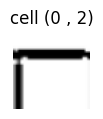

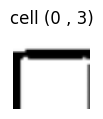

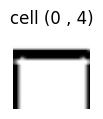

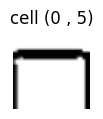

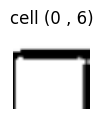

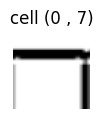

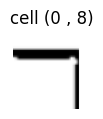

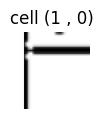

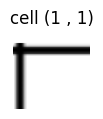

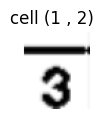

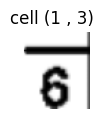

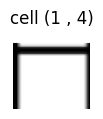

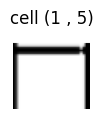

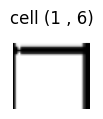

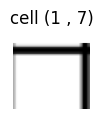

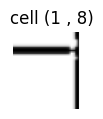

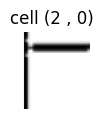

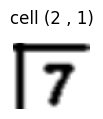

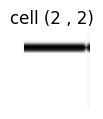

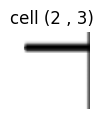

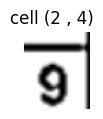

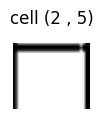

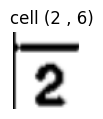

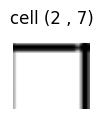

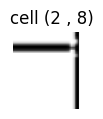

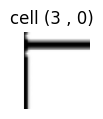

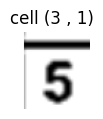

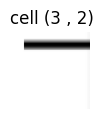

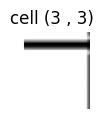

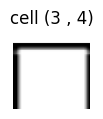

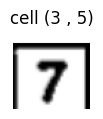

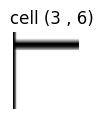

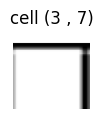

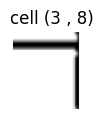

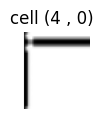

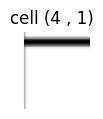

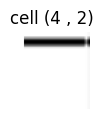

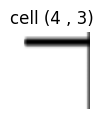

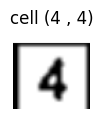

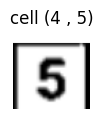

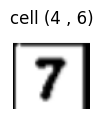

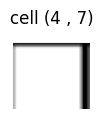

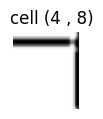

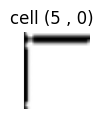

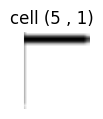

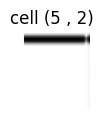

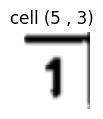

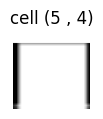

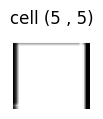

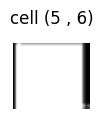

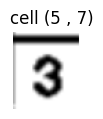

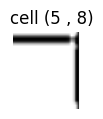

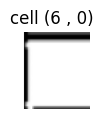

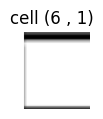

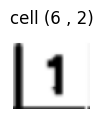

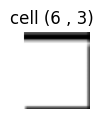

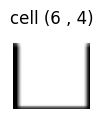

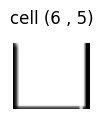

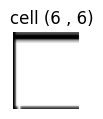

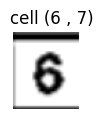

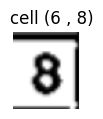

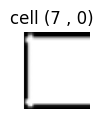

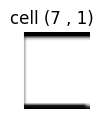

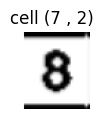

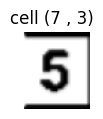

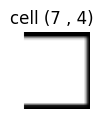

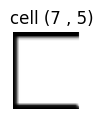

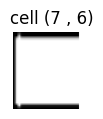

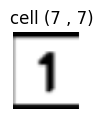

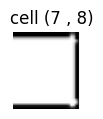

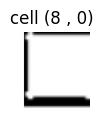

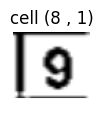

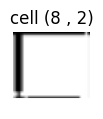

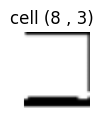

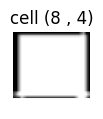

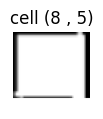

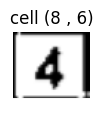

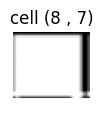

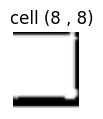

[[ 0  0  0  0  0  0  0  0  0]
 [ 0  0  3  7  0  0  0  0  0]
 [ 0  0  0  0  9  0  2  0  0]
 [ 0  5  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  5  0  0  0]
 [ 0  0  0 77  0  0  0  3  0]
 [ 0  0  0  0  0  0  0  6  8]
 [ 0  0  8  5  0  0  0  0  0]
 [ 0  9  0  0  0  0  0  0  0]]


In [ ]:
import cv2
import numpy as np

def remove_grid_based_on_black_density(cell, threshold=50):
    """
    セルの画像を4等分し、黒いピクセルの多い部分を判定して適切なエッジを白くする

    :param cell: セルの画像（グレースケール or BGR）
    :param threshold: ピクセルのRGB値の合計がこの値を超えないと黒と判定
    :return: グリッド線除去後のセル画像
    """
    h, w = cell.shape[:2]

    # グレースケール変換（もしカラーなら）
    if len(cell.shape) == 3:
        cell_gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
    else:
        cell_gray = cell.copy()

    # 画像を4等分
    h_half, w_half = h // 2, w // 2
    segments = {
        "top_left": cell_gray[:h_half, :w_half],
        "top_right": cell_gray[:h_half, w_half:],
        "bottom_left": cell_gray[h_half:, :w_half],
        "bottom_right": cell_gray[h_half:, w_half:]
    }

    # 各部分の黒いピクセル数をカウント
    black_counts = {key: np.sum(value < threshold) for key, value in segments.items()}

    # 黒いピクセルが多い上位2つを取得
    sorted_areas = sorted(black_counts.items(), key=lambda x: x[1], reverse=True)
    top_two = {sorted_areas[0][0], sorted_areas[1][0]}

    # 画像のコピーを作成
    processed_cell = cell.copy()

    # 白くするエリアの割合
    erase_ratio = 0.15

    def erase_region(region):
        """ 指定された領域を白くする """
        if region == "left":
            processed_cell[:, :int(w * erase_ratio)] = 255
        elif region == "right":
            processed_cell[:, -int(w * erase_ratio):] = 255
        elif region == "top":
            processed_cell[:int(h * erase_ratio), :] = 255
        elif region == "bottom":
            processed_cell[-int(h * erase_ratio):, :] = 255

    # 黒いピクセルが多い領域に応じてエッジを白くする
    if {"top_left", "top_right"} <= top_two:
        erase_region("top")
    if {"bottom_left", "bottom_right"} <= top_two:
        erase_region("bottom")
    if {"top_left", "bottom_left"} <= top_two:
        erase_region("left")
    if {"top_right", "bottom_right"} <= top_two:
        erase_region("right")

    if {"top_left", "bottom_right"} <= top_two or {"top_right", "bottom_left"} <= top_two:
        erase_region("top")
        erase_region("bottom")
        erase_region("left")
        erase_region("right")

    return processed_cell

def remove_grid_edges(cell, threshold=192):
    """
    画像の端が黒（0,0,0）の場合、その方向にスキャンし、
    RGB値の合計が閾値を超えないピクセルを白（255,255,255）に変更する。

    :param cell: 処理対象のセル画像（カラー画像）
    :param threshold: ピクセルのRGB値の合計がこの値を超えると処理を終了する
    :return: グリッド線が除去されたセル画像
    """
    h, w = cell.shape[:2]

    # カラー画像を取得
    if len(cell.shape) == 2:
        cell = cv2.cvtColor(cell, cv2.COLOR_GRAY2BGR)

    # 端からスキャンしてグリッド線を白にする関数
    def process_edge(start_x, start_y, dx, dy):
        """ 指定方向にスキャンし、閾値を超えるまで黒を白に変換 """
        x, y = start_x, start_y
        while 0 <= x < w and 0 <= y < h:
            r, g, b = cell[y, x]
            if r + g + b >= threshold:  # 閾値を超えたら終了
                break
            cell[y, x] = (255, 255, 255)  # 白に変換
            x += dx
            y += dy

    # 左端が黒なら、左→右へスキャン
    if np.all(cell[:, 0] == 0):
        for y in range(h):
            process_edge(0, y, 1, 0)

    # 右端が黒なら、右→左へスキャン
    if np.all(cell[:, -1] == 0):
        for y in range(h):
            process_edge(w - 1, y, -1, 0)

    # 上端が黒なら、上→下へスキャン
    if np.all(cell[0, :] == 0):
        for x in range(w):
            process_edge(x, 0, 0, 1)

    # 下端が黒なら、下→上へスキャン
    if np.all(cell[-1, :] == 0):
        for x in range(w):
            process_edge(x, h - 1, 0, -1)

    return cell


def preprocess_image(image_path):
    """ 画像を前処理して数独盤面を抽出 """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    return img

def find_largest_contour(image):
    """ 最大の四角形（数独盤面）を検出 """
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:
            return approx
    return None

def warp_perspective(image, contour):
    """ 数独盤面を透視変換して正面からのビューに補正 """
    pts = np.array([c[0] for c in contour], dtype='float32')
    if pts.shape[0] != 4:
        raise ValueError("エラー: 輪郭の頂点が4点ではありません。")

    # 頂点の順番を並び替え
    rect = order_points(pts)

    side = max(np.linalg.norm(rect[0] - rect[2]), np.linalg.norm(rect[1] - rect[3]))
    dst = np.array([[0, 0], [side - 1, 0], [0, side - 1], [side - 1, side - 1]], dtype='float32')
    matrix = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, matrix, (int(side), int(side)))
    return warped

def extract_digits_easyocr(warped_image):
    """ 9×9 のセルを切り出して EasyOCR で数字を認識 """
    reader = easyocr.Reader(['en'])
    grid = np.zeros((9, 9), dtype=int)
    cell_size = warped_image.shape[0] // 9

    for i in range(9):
        for j in range(9):
            x, y = j * cell_size, i * cell_size
            cell = warped_image[y:y + cell_size, x:x + cell_size]
            cell = remove_grid_based_on_black_density(cv2.resize(cell, (56, 56)))

            # **画像を表示**
            plt.figure(figsize=(1, 1))
            plt.imshow(cell, cmap='gray')
            plt.title(f"cell ({i} , {j})")
            plt.axis("off")
            plt.show()

            # EasyOCR で文字認識
            results = reader.readtext(cell, detail=0)
            digit = ''.join([r for r in results if r.isdigit()])
            grid[i, j] = int(digit) if digit else 0

    return grid

def process_sudoku(image_path):
    """ 画像から数独の2Dリストを生成 """
    img = preprocess_image(image_path)
    contour = find_largest_contour(img)
    if contour is None:
        raise ValueError("数独の盤面が見つかりませんでした。")

    warped = warp_perspective(img, contour)
    return extract_digits_easyocr(warped)

# 使用例
image_path = "sudoku.jpg"  # 画像のパス
sudoku_grid = process_sudoku(image_path)
print(sudoku_grid)


![](sudoku.jpg)

# 複数の文字が検出された場合は、一番大きい数字を採用する